In [1]:
!pip install -q tensorflow==2.0.0-beta1

tensorflow-serving-api 1.14.0 has requirement tensorflow~=1.14.0, but you'll have tensorflow 2.0.0b1 which is incompatible.
You are using pip version 10.0.1, however version 19.3.1 is available.
You should consider upgrading via the 'pip install --upgrade pip' command.


In [2]:
!pip install -q statsmodels==0.9.0

tensorflow-serving-api 1.14.0 has requirement tensorflow~=1.14.0, but you'll have tensorflow 2.0.0b1 which is incompatible.
You are using pip version 10.0.1, however version 19.3.1 is available.
You should consider upgrading via the 'pip install --upgrade pip' command.


In [3]:
!pip install -q scipy==1.2

tensorflow-serving-api 1.14.0 has requirement tensorflow~=1.14.0, but you'll have tensorflow 2.0.0b1 which is incompatible.
You are using pip version 10.0.1, however version 19.3.1 is available.
You should consider upgrading via the 'pip install --upgrade pip' command.


In [4]:
import os
import csv
import random
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.preprocessing import MinMaxScaler

dtypes = {
        'IsCanceled':                                    'float64',
        'LeadTime':                                          'float64',
        'StaysInWeekendNights':                                     'float64',
        'StaysInWeekNights':                                     'float64',
        'Adults':                            'float64',
        'Children':                            'float64',
        'Babies':                                  'float64',
        'Meal':                                    'category',
        'Country':                                               'category',
        'MarketSegment':                                    'category',
        'DistributionChannel':                                       'category',
        'IsRepeatedGuest':                               'float64',
        'PreviousCancellations':                                    'float64',
        'PreviousBookingsNotCanceled':                          'float64',
        'ReservedRoomType':                                             'category',
        'AssignedRoomType':                                            'category',
        'BookingChanges':                                                'float64',
        'DepositType':                                              'category',
        'Agent':                                              'category',
        'Company':                                 'category',
        'DaysInWaitingList':                                           'float64',
        'CustomerType':                                           'category',
        'ADR':                                          'float64',
        'RequiredCarParkingSpaces':                                      'float64',
        'TotalOfSpecialRequests':                                              'float64',
        'ReservationStatus':                                                'category'
        }

In [5]:
train_df = pd.read_csv('H2.csv', dtype=dtypes, converters={'ArrivalDateWeekNumber': '{:0>2}'.format})
a=train_df.head()
b=train_df
b
c=b.sort_values(['ArrivalDateYear','ArrivalDateWeekNumber'], ascending=True)
c=pd.DataFrame(c)
c
type(c)

pandas.core.frame.DataFrame

In [6]:
from pandas import DataFrame  

df = DataFrame(c, columns= ['ArrivalDateYear', 'ArrivalDateWeekNumber']) 
df

,ArrivalDateYear,ArrivalDateWeekNumber
1079,2015,27
1748,2015,27
2137,2015,27
2374,2015,27
2434,2015,27
2633,2015,27
3355,2015,27
3434,2015,27
3495,2015,27
3679,2015,27


In [7]:
# https://datatofish.com/concatenate-values-python/

df1 = df['ArrivalDateYear'].map(str) + df['ArrivalDateWeekNumber'].map(str)
print (df1)
df1=pd.DataFrame(df1)

1079     201527
1748     201527
2137     201527
2374     201527
2434     201527
2633     201527
3355     201527
3434     201527
3495     201527
3679     201527
4217     201527
4447     201527
4848     201527
5661     201527
7360     201527
7827     201527
8035     201527
8507     201527
9362     201527
10888    201527
11818    201527
921      201528
1235     201528
1951     201528
2079     201528
2306     201528
2649     201528
2992     201528
3278     201528
3786     201528
          ...  
6527     201735
6620     201735
6975     201735
7003     201735
7113     201735
7184     201735
7452     201735
7630     201735
7679     201735
8259     201735
8384     201735
8893     201735
9070     201735
9079     201735
9099     201735
9104     201735
9136     201735
9170     201735
9529     201735
9634     201735
10121    201735
10624    201735
10693    201735
10949    201735
11038    201735
11173    201735
11181    201735
11565    201735
11608    201735
11858    201735
Length: 12000, dtype: ob

In [8]:
df2 = DataFrame(c, columns= ['IsCanceled']) 
df2

,IsCanceled
1079,0.0
1748,1.0
2137,0.0
2374,1.0
2434,0.0
2633,1.0
3355,1.0
3434,1.0
3495,1.0
3679,0.0


In [9]:
type(df1)

pandas.core.frame.DataFrame

In [10]:
df3=pd.concat([df1, df2], axis = 1).T.drop_duplicates().T
df3
df3.columns = ['FullDate', 'IsCanceled']

In [11]:
df3
df3.sort_values(['FullDate','IsCanceled'], ascending=True)

,FullDate,IsCanceled
1079,201527,0
2137,201527,0
2434,201527,0
3679,201527,0
4217,201527,0
4447,201527,0
5661,201527,0
7827,201527,0
8035,201527,0
11818,201527,0


In [12]:
df4 = df3.groupby('FullDate').agg(sum)
df4
df4.sort_values(['FullDate'], ascending=True)

,IsCanceled
FullDate,
201527,11.0
201528,18.0
201529,32.0
201530,38.0
201531,24.0
201532,43.0
201533,54.0
201534,24.0
201535,34.0


In [13]:
tseries=df4['IsCanceled']
tseries

FullDate
201527     11.0
201528     18.0
201529     32.0
201530     38.0
201531     24.0
201532     43.0
201533     54.0
201534     24.0
201535     34.0
201536     45.0
201537     55.0
201538     66.0
201539     63.0
201540     41.0
201541     48.0
201542     57.0
201543     18.0
201544     37.0
201545      9.0
201546     15.0
201547      4.0
201548     14.0
201549     30.0
201550     27.0
201551      4.0
201552     11.0
201553     32.0
201601      6.0
201602      6.0
201603     11.0
          ...  
201706     28.0
201707     47.0
201708     37.0
201709     47.0
201710     38.0
201711     51.0
201712     42.0
201713     42.0
201714     52.0
201715     70.0
201716     77.0
201717     89.0
201718     84.0
201719     61.0
201720    117.0
201721     68.0
201722     72.0
201723     73.0
201724     63.0
201725     53.0
201726     63.0
201727     52.0
201728     58.0
201729     33.0
201730     48.0
201731     53.0
201732     50.0
201733     51.0
201734     38.0
201735     20.0
Name: IsCancele

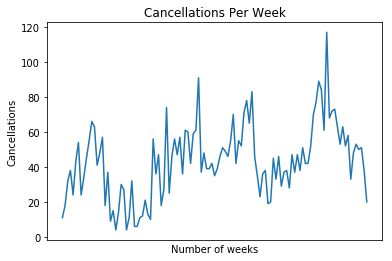

In [14]:
import matplotlib.pyplot as plt
plt.plot(tseries)
plt.tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=False) # labels along the bottom edge are off
plt.xlabel('Number of weeks')
plt.ylabel('Cancellations')
plt.title("Cancellations Per Week")
plt.show()

In [15]:
df=pd.DataFrame(tseries)
df

,IsCanceled
FullDate,
201527,11.0
201528,18.0
201529,32.0
201530,38.0
201531,24.0
201532,43.0
201533,54.0
201534,24.0
201535,34.0


In [16]:
df = df[:100]

In [17]:
df

,IsCanceled
FullDate,
201527,11.0
201528,18.0
201529,32.0
201530,38.0
201531,24.0
201532,43.0
201533,54.0
201534,24.0
201535,34.0


In [18]:
# Form dataset matrix
def create_dataset(df, previous=1):
    dataX, dataY = [], []
    for i in range(len(df)-previous-1):
        a = df[i:(i+previous), 0]
        dataX.append(a)
        dataY.append(df[i + previous, 0])
    return np.array(dataX), np.array(dataY)

In [19]:
# normalize dataset with MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
df = scaler.fit_transform(df)
df

array([[0.0619469 ],
       [0.12389381],
       [0.24778761],
       [0.30088496],
       [0.17699115],
       [0.34513274],
       [0.44247788],
       [0.17699115],
       [0.26548673],
       [0.36283186],
       [0.45132743],
       [0.54867257],
       [0.52212389],
       [0.32743363],
       [0.38938053],
       [0.46902655],
       [0.12389381],
       [0.2920354 ],
       [0.04424779],
       [0.09734513],
       [0.        ],
       [0.08849558],
       [0.2300885 ],
       [0.20353982],
       [0.        ],
       [0.0619469 ],
       [0.24778761],
       [0.01769912],
       [0.01769912],
       [0.0619469 ],
       [0.07079646],
       [0.15044248],
       [0.07964602],
       [0.05309735],
       [0.46017699],
       [0.28318584],
       [0.38053097],
       [0.12389381],
       [0.20353982],
       [0.61946903],
       [0.18584071],
       [0.37168142],
       [0.46017699],
       [0.38053097],
       [0.46902655],
       [0.28318584],
       [0.50442478],
       [0.495

In [20]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM

# Training and Validation data partition
train_size = int(len(df) * 0.8)
val_size = len(df) - train_size
train, val = df[0:train_size,:], df[train_size:len(df),:]

# Number of previous
previous = 2
X_train, Y_train = create_dataset(train, previous)
X_val, Y_val = create_dataset(val, previous)

# reshape input to be [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_val = np.reshape(X_val, (X_val.shape[0], 1, X_val.shape[1]))

# Generate LSTM network
model = tf.keras.Sequential()
model.add(LSTM(4, input_shape=(1, previous)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(X_train, Y_train, epochs=150, batch_size=1, verbose=2)

Train on 77 samples
Epoch 1/150
77/77 - 1s - loss: 0.0847
Epoch 2/150
77/77 - 0s - loss: 0.0465
Epoch 3/150
77/77 - 0s - loss: 0.0292
Epoch 4/150
77/77 - 0s - loss: 0.0247
Epoch 5/150
77/77 - 0s - loss: 0.0238
Epoch 6/150
77/77 - 0s - loss: 0.0233
Epoch 7/150
77/77 - 0s - loss: 0.0228
Epoch 8/150
77/77 - 0s - loss: 0.0227
Epoch 9/150
77/77 - 0s - loss: 0.0226
Epoch 10/150
77/77 - 0s - loss: 0.0221
Epoch 11/150
77/77 - 0s - loss: 0.0216
Epoch 12/150
77/77 - 0s - loss: 0.0216
Epoch 13/150
77/77 - 0s - loss: 0.0211
Epoch 14/150
77/77 - 0s - loss: 0.0209
Epoch 15/150
77/77 - 0s - loss: 0.0209
Epoch 16/150
77/77 - 0s - loss: 0.0208
Epoch 17/150
77/77 - 0s - loss: 0.0206
Epoch 18/150
77/77 - 0s - loss: 0.0204
Epoch 19/150
77/77 - 0s - loss: 0.0203
Epoch 20/150
77/77 - 0s - loss: 0.0201
Epoch 21/150
77/77 - 0s - loss: 0.0201
Epoch 22/150
77/77 - 0s - loss: 0.0200
Epoch 23/150
77/77 - 0s - loss: 0.0201
Epoch 24/150
77/77 - 0s - loss: 0.0199
Epoch 25/150
77/77 - 0s - loss: 0.0200
Epoch 26/150
7

In [21]:
# Generate predictions
trainpred = model.predict(X_train)
valpred = model.predict(X_val)

In [22]:
trainpred

array([[0.17191234],
       [0.24907914],
       [0.30662602],
       [0.26259387],
       [0.3059375 ],
       [0.38923216],
       [0.30250204],
       [0.2714443 ],
       [0.3373986 ],
       [0.39720994],
       [0.45172766],
       [0.47133332],
       [0.39559728],
       [0.36500975],
       [0.4105323 ],
       [0.28194568],
       [0.26908958],
       [0.18808451],
       [0.15362465],
       [0.11329155],
       [0.13827625],
       [0.23148763],
       [0.25644705],
       [0.1395317 ],
       [0.12419201],
       [0.23286259],
       [0.1611297 ],
       [0.10434324],
       [0.12836987],
       [0.14378603],
       [0.18779919],
       [0.17073742],
       [0.13850088],
       [0.315895  ],
       [0.35871178],
       [0.34926242],
       [0.2568676 ],
       [0.22800258],
       [0.4022979 ],
       [0.3581986 ],
       [0.31899452],
       [0.40266076],
       [0.3991183 ],
       [0.40805796],
       [0.36124897],
       [0.39229646],
       [0.45113698],
       [0.391

In [23]:
valpred

array([[0.33844483],
       [0.30451468],
       [0.29542658],
       [0.31891719],
       [0.28031233],
       [0.32970387],
       [0.33993578],
       [0.35172635],
       [0.3438268 ],
       [0.36747235],
       [0.36892784],
       [0.346395  ],
       [0.3805395 ],
       [0.4537477 ],
       [0.51175636],
       [0.54761356],
       [0.5684838 ]], dtype=float32)

In [24]:
# Convert predictions back to normal values
trainpred = scaler.inverse_transform(trainpred)
Y_train = scaler.inverse_transform([Y_train])
valpred = scaler.inverse_transform(valpred)
Y_val = scaler.inverse_transform([Y_val])
predictions = valpred

In [25]:
import math
from sklearn.metrics import mean_squared_error

# calculate RMSE
trainScore = math.sqrt(mean_squared_error(Y_train[0], trainpred[:,0]))
print('Train Score: %.2f RMSE' % (trainScore))
valScore = math.sqrt(mean_squared_error(Y_val[0], valpred[:,0]))
print('Validation Score: %.2f RMSE' % (valScore))

Train Score: 15.59 RMSE
Validation Score: 12.87 RMSE


In [26]:
# Train predictions
trainpredPlot = np.empty_like(df)
trainpredPlot[:, :] = np.nan
trainpredPlot[previous:len(trainpred)+previous, :] = trainpred

In [27]:
# Validation predictions
valpredPlot = np.empty_like(df)
valpredPlot[:, :] = np.nan
valpredPlot[len(trainpred)+(previous*2)+1:len(df)-1, :] = valpred

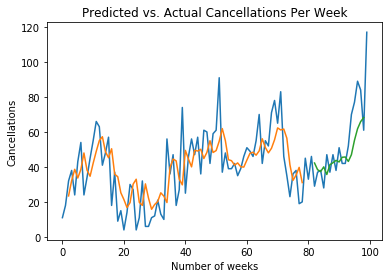

In [28]:
# Plot all predictions
inversetransform, =plt.plot(scaler.inverse_transform(df))
trainpred, =plt.plot(trainpredPlot)
valpred, =plt.plot(valpredPlot)
plt.xlabel('Number of weeks')
plt.ylabel('Cancellations')
plt.title("Predicted vs. Actual Cancellations Per Week")
plt.show()

In [29]:
Y_val=Y_val.reshape(-1)
Y_val.shape
Y_val=pd.Series(Y_val)

In [30]:
predictions=predictions.reshape(-1)
predictions.shape
predictions=pd.Series(predictions)

In [31]:
import numpy as np

def mda(actual: np.ndarray, predicted: np.ndarray):
    """ Mean Directional Accuracy """
    return np.mean((np.sign(actual[1:] - actual[:-1]) == np.sign(predicted[1:] - predicted[:-1])).astype(int))

In [32]:
mda(Y_val, predictions)

0.8823529411764706

In [33]:
X_train

array([[[0.0619469 , 0.12389381]],

       [[0.12389381, 0.24778761]],

       [[0.24778761, 0.30088496]],

       [[0.30088496, 0.17699115]],

       [[0.17699115, 0.34513274]],

       [[0.34513274, 0.44247788]],

       [[0.44247788, 0.17699115]],

       [[0.17699115, 0.26548673]],

       [[0.26548673, 0.36283186]],

       [[0.36283186, 0.45132743]],

       [[0.45132743, 0.54867257]],

       [[0.54867257, 0.52212389]],

       [[0.52212389, 0.32743363]],

       [[0.32743363, 0.38938053]],

       [[0.38938053, 0.46902655]],

       [[0.46902655, 0.12389381]],

       [[0.12389381, 0.2920354 ]],

       [[0.2920354 , 0.04424779]],

       [[0.04424779, 0.09734513]],

       [[0.09734513, 0.        ]],

       [[0.        , 0.08849558]],

       [[0.08849558, 0.2300885 ]],

       [[0.2300885 , 0.20353982]],

       [[0.20353982, 0.        ]],

       [[0.        , 0.0619469 ]],

       [[0.0619469 , 0.24778761]],

       [[0.24778761, 0.01769912]],

       [[0.01769912, 0.01769

In [34]:
# Test (unseen) predictions
# (t) and (t-2)
Xnew = np.array([[73, 68],[63,72],[53, 73],[63,63],[52, 53],[58,63],[33, 52],[48,58],[53, 33],[50,48],[51, 53],[38,50]])
Xnew = scaler.fit_transform(Xnew)
Xnew
Xnewformat = np.reshape(Xnew, (Xnew.shape[0], 1, Xnew.shape[1]))
ynew=model.predict(Xnewformat)

In [35]:
ynew

array([[0.6520772 ],
       [0.59751284],
       [0.5350314 ],
       [0.5746082 ],
       [0.44425446],
       [0.5417036 ],
       [0.30707356],
       [0.45006382],
       [0.21920067],
       [0.38700137],
       [0.4372679 ],
       [0.3226382 ]], dtype=float32)

In [36]:
type(ynew)

numpy.ndarray

In [37]:
ynew.shape

(12, 1)

In [38]:
actual = np.array([[63,53,63,52,58,33,48,53,50,51,38,20]])
actual = (actual - np.min(actual))/np.ptp(actual)
actual

array([[1.        , 0.76744186, 1.        , 0.74418605, 0.88372093,
        0.30232558, 0.65116279, 0.76744186, 0.69767442, 0.72093023,
        0.41860465, 0.        ]])

In [39]:
actual.shape

(1, 12)

In [40]:
actual=actual.reshape(12,-1)
actual.shape

(12, 1)

In [41]:
actual

array([[1.        ],
       [0.76744186],
       [1.        ],
       [0.74418605],
       [0.88372093],
       [0.30232558],
       [0.65116279],
       [0.76744186],
       [0.69767442],
       [0.72093023],
       [0.41860465],
       [0.        ]])

In [42]:
ynew=ynew.reshape(-1)
actual=actual.reshape(-1)
actualpd=pd.Series(actual)
ynewpd=pd.Series(ynew)

In [43]:
actualpd

0     1.000000
1     0.767442
2     1.000000
3     0.744186
4     0.883721
5     0.302326
6     0.651163
7     0.767442
8     0.697674
9     0.720930
10    0.418605
11    0.000000
dtype: float64

In [44]:
ynewpd

0     0.652077
1     0.597513
2     0.535031
3     0.574608
4     0.444254
5     0.541704
6     0.307074
7     0.450064
8     0.219201
9     0.387001
10    0.437268
11    0.322638
dtype: float32

In [45]:
mda(actualpd, ynewpd)

0.8333333333333334